<a href="https://colab.research.google.com/github/kaves29/hybrid_algo_bot/blob/main/science_fair_trading_bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SETUP AND CALIBRATION

!pip install yfinance ta tabulate xgboost

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ta.trend import SMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from tabulate import tabulate
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ca130f6c12ea005aa1f0eea6397c260987ca475b98788da8cadc053337b20054
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# DOWNLOADING NECESSARY DATA

# List of stocks
stock = ['AAPL', 'MSFT', 'JNJ', 'JPM', 'KO', 'TSLA', 'PG']
benchmark_stock = '^SP500TR'

# Downloading historical data
historical_data = yf.download(stock, start='2020-09-01', end='2025-10-01', group_by='ticker', auto_adjust=True)
spy_data = yf.download(benchmark_stock, start='2022-10-01', end='2025-10-01')

# Creating dictionary containing closing prices
close_price = {ticker: historical_data[ticker]['Close'] for ticker in stock}

spy_close = spy_data['Close']

# Changing into single DataFrame
df = pd.DataFrame(close_price)


[*********************100%***********************]  7 of 7 completed
/tmp/ipython-input-1061781046.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download(benchmark_stock, start='2022-10-01', end='2025-10-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
# FORMATING DATAFRAME AND CALCULATING INDICATORS
stock_dfs = {} # Dictionary to hold each stock's DataFrame data

for ticker in stock:
  df_stock = pd.DataFrame() # Creating DataFrame for current stock

  df_stock['Close'] = df[ticker] # Adding closing value to DataFrame
  current_stock_close_price = df[ticker] # grabbing closing data of current stock
  sma50 = SMAIndicator(close=current_stock_close_price, window=50).sma_indicator() # grabbing SMA of current stock
  lma200 = SMAIndicator(close=current_stock_close_price, window=200).sma_indicator() # grabbing LMA of current stock
  rsi14 = RSIIndicator(close=current_stock_close_price, window=14).rsi() # grabbing RSI14
  macd = MACD(close=current_stock_close_price).macd() # grabbing MACD
  signal = MACD(close=current_stock_close_price).macd_signal() # grabbing MACD signal
  boll_bands = BollingerBands(close=current_stock_close_price, window=20, window_dev=2) # grabbing Bollinger Bands
  atr = AverageTrueRange(high=historical_data[ticker]['High'], low=historical_data[ticker]['Low'], close=current_stock_close_price, window=14).average_true_range()

  # Adding indicators as new colums in DataFrame
  df_stock['_SMA50'] = sma50
  df_stock['_LMA200'] = lma200
  df_stock['_RSI14'] = rsi14
  df_stock['_MACD'] = macd
  df_stock['_MACD_signal'] = signal
  df_stock['_BB_high'] = boll_bands.bollinger_hband()
  df_stock['_BB_low'] = boll_bands.bollinger_lband()
  df_stock['_ATR'] = atr
  df_stock['ProfitLabel'] = (df_stock['Close'].shift(-1) > df_stock['Close']).astype(int)

  stock_dfs[ticker] = df_stock # Storing values in dictionary

multiindex_df = pd.concat(stock_dfs, axis=1) # Combining all stocks into a MultiIndex DataFrame
multiindex_df.columns = [f"{ticker}_{col}" for ticker, col in multiindex_df.columns]

# Setting training and testing
train_start = '2020-09-01'
train_end = '2022-09-01'
test_start = '2022-10-01'
test_end = '2025-10-01'

train_df = multiindex_df.loc[train_start:train_end].copy()
test_df = multiindex_df.loc[test_start:test_end].copy()

In [ ]:
# TRAINING FOR ML MODEL
features = []
target_profit = 1.03 # 3%
prediction_days = 10 # check target over 10 days

# Key metrics at time of trade
for ticker in stock:
  df_close = train_df[f'{ticker}_Close']

  for i in range (len(df_close) - prediction_days):
    # current day indicators
    try:
      current_features = {
      'SMA50': train_df[f'{ticker}__SMA50'].iloc[i],
      'LMA200': train_df[f'{ticker}__LMA200'].iloc[i],
      'RSI14': train_df[f'{ticker}__RSI14'].iloc[i],
      'MACD': train_df[f'{ticker}__MACD'].iloc[i],
      'MACD_signal': train_df[f'{ticker}__MACD_signal'].iloc[i],
      'BB_high': train_df[f'{ticker}__BB_high'].iloc[i],
      'BB_low': train_df[f'{ticker}__BB_low'].iloc[i],
      'ATR': train_df[f'{ticker}__ATR'].iloc[i],

}

    except KeyError:
      continue

    # skip days with no datat
    if any(pd.isna(value) for value in current_features.values()):
      continue

    current_price = df_close.iloc[i]
    future_prices = df_close.iloc[i + 1 : i + 1 + prediction_days]

    # check if profit target hit
    winning_trade = 0
    if not future_prices.empty and future_prices.max() >= current_price * target_profit:
      winning_trade = 1

    current_features['ProfitLabel'] = winning_trade
    features.append(current_features)

features_df = pd.DataFrame(features)
features_df.dropna(inplace=True)


X = features_df.drop(columns=['ProfitLabel'])
Y = features_df['ProfitLabel']

X_train, X_test_val, Y_train, Y_test_val = train_test_split(X, Y, test_size=0.3, shuffle=False)

xgb_model = XGBClassifier(
    max_depth=1,
    learning_rate=0.1,
    random_state=42,
    colsample_bytree=0.8,
    subsample=0.8,
    n_estimators=400,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, Y_train)
train_accuracy = xgb_model.score(X_train, Y_train)
validation_accuracy = xgb_model.score(X_test_val, Y_test_val)

print("\nML Feature creation and model training complete.")
print(f"ML Model Training Accuracy: {train_accuracy:.4f}")
print(f"ML Model Validation Accuracy (X_test): {validation_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:16:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



ML Feature creation and model training complete.
ML Model Training Accuracy: 0.7483
ML Model Validation Accuracy (X_test): 0.5981


In [ ]:
# BOT TRADE LOGIC

# setting up bot for testing period
portfolio_state = {'cash': 10000, 'positions': {}, 'trade history': []}
wins = 0
losses = 0
starting_cash = 10000
transaction_fee = 0.0005
slippage_rate = 0.0002

# getting indicators for each day of the test
for date in test_df.index:
  for ticker in stock:
    current_stock_close_price = test_df[f'{ticker}_Close'].loc[date]
    sma50 = test_df[f'{ticker}__SMA50'].loc[date]
    lma200 = test_df[f'{ticker}__LMA200'].loc[date]
    rsi14 = test_df[f'{ticker}__RSI14'].loc[date]
    macd = test_df[f'{ticker}__MACD'].loc[date]
    macd_signal = test_df[f'{ticker}__MACD_signal'].loc[date]
    boll_bands_high = test_df[f'{ticker}__BB_high'].loc[date]
    boll_bands_low = test_df[f'{ticker}__BB_low'].loc[date]
    atr = test_df[f'{ticker}__ATR'].loc[date]

    # skipping days with no data
    if pd.isna(sma50) or pd.isna(lma200) or pd.isna(rsi14) or pd.isna(macd) or pd.isna(macd_signal) or pd.isna(boll_bands_high) or pd.isna(boll_bands_low) or pd.isna(atr):
      continue

    current_feature = {
        'SMA50': sma50,
        'LMA200': lma200,
        'RSI14': rsi14,
        'MACD': macd,
        'MACD_signal': macd_signal,
        'BB_high': boll_bands_high,
        'BB_low': boll_bands_low,
        'ATR': atr
    }

    # buy conditions
    shares_to_buy = 0
    if atr > (current_stock_close_price * 0.03) and (boll_bands_high - boll_bands_low) > (current_stock_close_price * 0.04):
      max_alloc = 0.25

      if sma50 > lma200 and rsi14 < 70 and macd > macd_signal:
        shares_to_buy = int((portfolio_state['cash'] * 0.1) // current_stock_close_price)

      elif sma50 > lma200 and rsi14 < 70:
        shares_to_buy = int((portfolio_state['cash'] * 0.05) // current_stock_close_price)

      elif sma50 > lma200:
        shares_to_buy = int((portfolio_state['cash'] * 0.03) // current_stock_close_price)

    else: # nonvolatile market
      max_alloc = 0.35
      if sma50 > lma200 and rsi14 < 70 and macd > macd_signal:
        shares_to_buy = int((portfolio_state['cash'] * 0.15) // current_stock_close_price)

      elif sma50 > lma200 and rsi14 < 70:
        shares_to_buy = int((portfolio_state['cash'] * 0.1) // current_stock_close_price)

      elif sma50 > lma200:
        shares_to_buy = int((portfolio_state['cash'] * 0.05) // current_stock_close_price)


    # adjusting amount to buy
    threshold = 0.6
    prediction_probability = xgb_model.predict_proba(pd.DataFrame([current_feature]))[0][1]

    if shares_to_buy > 0 and prediction_probability > threshold:
      effective_buy_price = current_stock_close_price * (1 + slippage_rate)

      positions_value = sum(pos['shares'] * current_stock_close_price for pos in portfolio_state['positions'].values())
      total_portfolio_value = portfolio_state['cash'] + positions_value
      current_stock_value = portfolio_state['positions'][ticker]['shares'] * current_stock_close_price if ticker in portfolio_state['positions'] else 0
      max_allowed_value = total_portfolio_value * max_alloc

      max_shares_allowed = int((max_allowed_value - current_stock_value) // effective_buy_price)
      shares_to_buy = min(shares_to_buy, max_shares_allowed)

      total_cost = shares_to_buy * effective_buy_price * (1 + transaction_fee)

      # portfolio update
      if shares_to_buy > 0 and portfolio_state['cash'] >= total_cost:
        portfolio_state['cash'] -= total_cost

        if ticker in portfolio_state['positions']:
          old_shares = portfolio_state['positions'][ticker]['shares']
          old_price = portfolio_state['positions'][ticker]['buy_price']
          total_shares = old_shares + shares_to_buy
          weighted_price = (old_price * old_shares + effective_buy_price * shares_to_buy) / total_shares
          portfolio_state['positions'][ticker] = {'shares': total_shares, 'buy_price': weighted_price }

        else:
          portfolio_state['positions'][ticker] = {'shares': shares_to_buy, 'buy_price': effective_buy_price}

        portfolio_state['trade history'].append({
            'date': date,
            'ticker': ticker,
            'action': 'buy',
            'shares': shares_to_buy,
            'fee': transaction_fee,
            'price': effective_buy_price
        })

    # conditions to sell
    if ticker in portfolio_state['positions'] and portfolio_state['positions'][ticker]['shares'] > 0:
      shares_held = portfolio_state['positions'][ticker]['shares']
      buy_price = portfolio_state['positions'][ticker]['buy_price']
      sell_shares = 0

      if current_stock_close_price >= buy_price + (3 * atr): # take profit value
        sell_shares = shares_held

      elif current_stock_close_price <= buy_price - (2 * atr): # take loss value
        sell_shares = shares_held

      elif sma50 < lma200 and macd < macd_signal:
        sell_shares = int(shares_held * 0.3)

      elif rsi14 > 75:
        sell_shares = int(shares_held * 0.25)

      # adjusting ammount to sell
      if sell_shares > 0:
        effective_sell_price = current_stock_close_price * (1 - slippage_rate)
        gross_sell_value = sell_shares * effective_sell_price
        net_sell_value = gross_sell_value * (1 - transaction_fee)

        # portfolio update
        portfolio_state['cash'] += net_sell_value

        pnl = net_sell_value - (buy_price * sell_shares)

        if pnl > 0:
          wins += 1
        elif pnl < 0:
          losses += 1
        else:
          continue

        portfolio_state['trade history'].append({
            'date': date,
            'ticker': ticker,
            'action': 'sell',
            'shares': sell_shares,
            'pnl': pnl,
            'fee': transaction_fee,
            'price': effective_sell_price
        })

        # remaining shares all sold at the end of test
        remaining_shares = shares_held - sell_shares
        if remaining_shares > 0:
            portfolio_state['positions'][ticker]['shares'] = remaining_shares
            portfolio_state['positions'][ticker]['buy_price'] = buy_price
        else:
            portfolio_state['positions'].pop(ticker)


In [ ]:
# SPY PASSIVE INVESTING
spy_cash = 10000.0
transaction_fee = 0.0005
slippage_rate = 0.0002

# --- BUY ---
spy_start_price = spy_data['Close'].iloc[0].item()
effective_buy_price = spy_start_price * (1 + slippage_rate)

# Buy only whole shares
spy_shares = int(spy_cash // effective_buy_price)

# Total cost including fees
spy_buy_cost = spy_shares * effective_buy_price * (1 + transaction_fee)

# Remaining cash after buy
spy_cash_remaining = spy_cash - spy_buy_cost

# --- SELL ---
spy_final_price = spy_data['Close'].iloc[-1].item()
effective_sell_price = spy_final_price * (1 - slippage_rate)

# Sell all shares
gross_sell_value = spy_shares * effective_sell_price
net_sell_value = gross_sell_value * (1 - transaction_fee)

# Final portfolio value including leftover cash
spy_final_value = net_sell_value + spy_cash_remaining

print(f"Shares purchased: {spy_shares}")
print(f"Cash remaining after buy: ${spy_cash_remaining:.2f}")
print(f"SPY final value: ${spy_final_value:.2f}")



Shares purchased: 1
Cash remaining after buy: $2194.54
SPY final value: $17010.96


--- BOT PERFORMANCE SUMMARY ---
Starting cash: $10,000.00
Final portfolio value: $13,661.84
Total Return: 36.62%
Winning to losing ratio: 65:49
Cash remaining (unused): $3,676.36



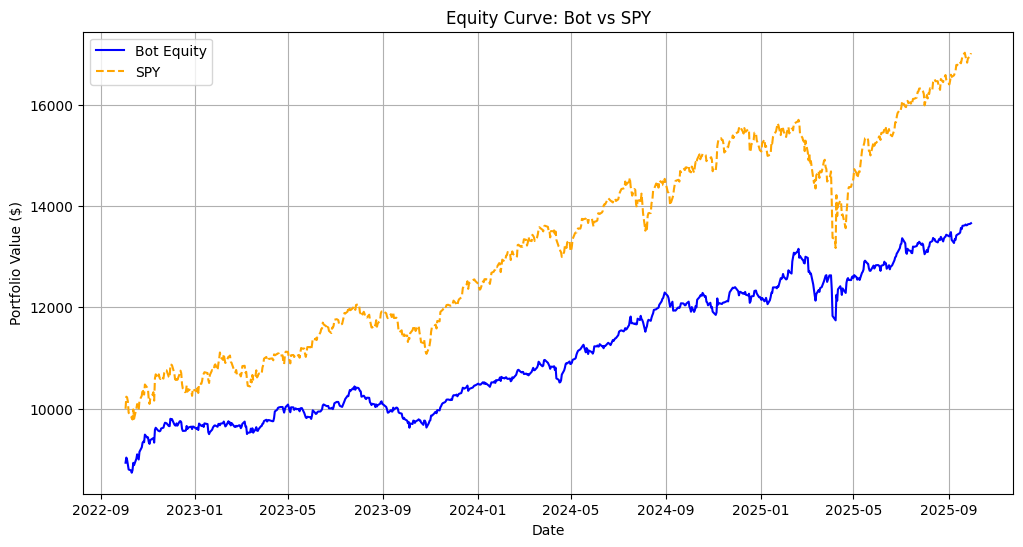

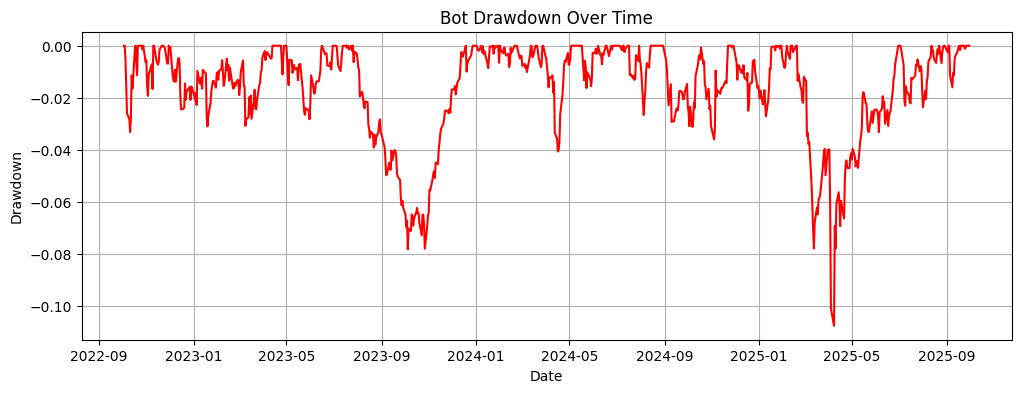

--- PERFORMANCE METRICS ---
+---------------+---------+
| Metric        | Value   |
+===============+=========+
| CAGR          | 10.98%  |
+---------------+---------+
| Sharpe Ratio  | 1.57    |
+---------------+---------+
| Sortino Ratio | 2.15    |
+---------------+---------+
| Max Drawdown  | -10.75% |
+---------------+---------+
| Win Rate      | 57.02%  |
+---------------+---------+
| Profit Factor | 1.32    |
+---------------+---------+

--- TRADE HISTORY ---
+-----+---------------------+----------+----------+----------+---------+------------+
|     | date                | ticker   | action   |   shares |   price |        pnl |
+=====+=====================+==========+==========+==========+=========+============+
|   0 | 2022-10-03 00:00:00 | AAPL     | buy      |        3 | 140.129 |  nan       |
+-----+---------------------+----------+----------+----------+---------+------------+
|   1 | 2022-10-03 00:00:00 | KO       | buy      |       18 |  51.408 |  nan       |
+-----+------

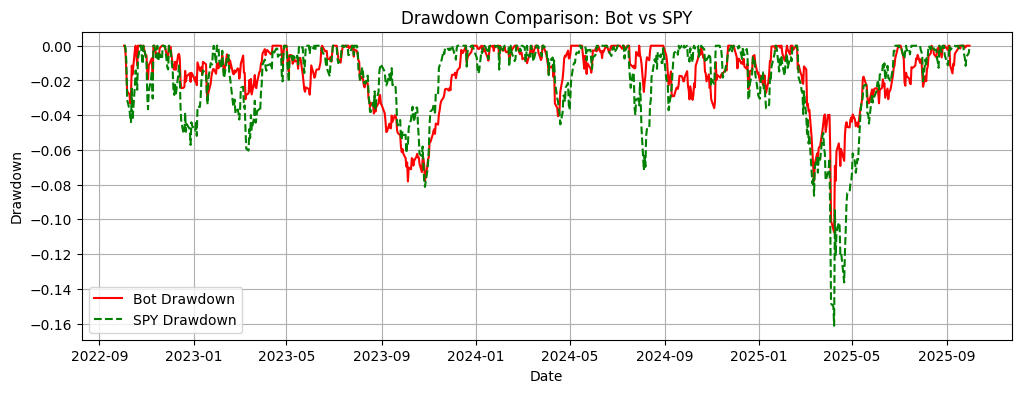

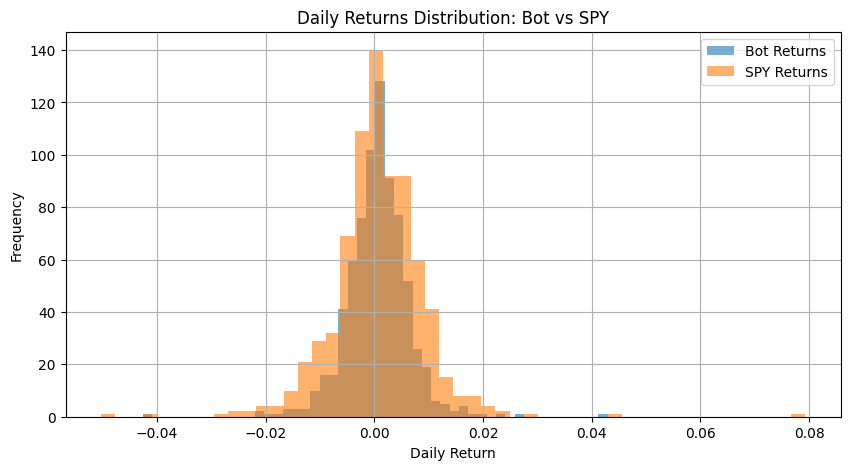

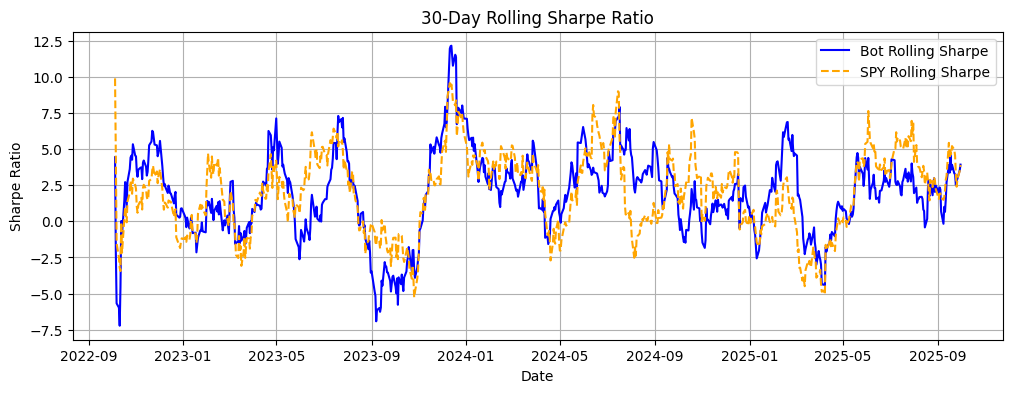

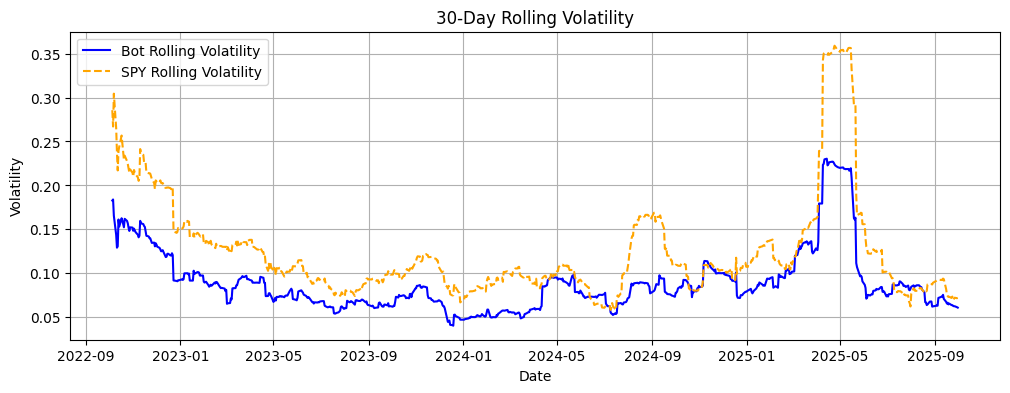

TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:
# NEEDS FIXING
# --- Compute Bot Equity ---
portfolio_equity = []
for date in test_df.index:
    total_value = portfolio_state['cash']
    for ticker, pos in portfolio_state['positions'].items():
        total_value += pos['shares'] * test_df[f'{ticker}_Close'].loc[date]
    portfolio_equity.append(total_value)

portfolio_equity = pd.Series(portfolio_equity, index=test_df.index)

# --- Compute SPY Equity ---
spy_equity = (spy_shares * spy_close) + spy_cash_remaining
spy_equity = spy_equity.reindex(portfolio_equity.index, method='ffill')


# --- Basic Summary ---
final_portfolio_value = portfolio_equity.iloc[-1]
total_return = (final_portfolio_value - starting_cash) / starting_cash * 100
winning_to_losing_ratio = f"{wins}:{losses}"
unused_cash = portfolio_state['cash']

print("--- BOT PERFORMANCE SUMMARY ---")
print(f"Starting cash: ${starting_cash:,.2f}")
print(f"Final portfolio value: ${final_portfolio_value:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"Winning to losing ratio: {winning_to_losing_ratio}")
print(f"Cash remaining (unused): ${unused_cash:,.2f}\n")

# --- Equity Curve ---
plt.figure(figsize=(12,6))
plt.plot(portfolio_equity, label='Bot Equity', color='blue')
plt.plot(spy_equity, label='SPY', color='orange', linestyle='--')
plt.title('Equity Curve: Bot vs SPY')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

# --- Drawdown Plot (Bot Only) ---
roll_max = portfolio_equity.cummax()
drawdown = (portfolio_equity - roll_max) / roll_max

plt.figure(figsize=(12,4))
plt.plot(drawdown, color='red')
plt.title('Bot Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.show()

# --- Performance Metrics ---
daily_returns = portfolio_equity.pct_change().dropna()
spy_returns = spy_equity.pct_change().dropna()
total_years = (portfolio_equity.index[-1] - portfolio_equity.index[0]).days / 365

CAGR = (final_portfolio_value / starting_cash) ** (1/total_years) - 1
sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
downside_std = daily_returns[daily_returns < 0].std()
sortino_ratio = daily_returns.mean() / downside_std * np.sqrt(252) if downside_std > 0 else np.nan
max_drawdown = drawdown.min()
win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0
profit_factor = sum(r for r in daily_returns if r > 0) / abs(sum(r for r in daily_returns if r < 0)) if any(daily_returns < 0) else np.nan

metrics = pd.DataFrame({
    'Metric': ['CAGR', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Win Rate', 'Profit Factor'],
    'Value': [f"{CAGR:.2%}", f"{sharpe_ratio:.2f}", f"{sortino_ratio:.2f}", f"{max_drawdown:.2%}", f"{win_rate:.2%}", f"{profit_factor:.2f}"]
})
print("--- PERFORMANCE METRICS ---")
print(tabulate(metrics, headers='keys', tablefmt='grid', showindex=False))

# --- Trade History ---
if portfolio_state['trade history']:
    trade_df = pd.DataFrame(portfolio_state['trade history'])
    trade_df['price'] = trade_df['price'].apply(lambda x: f"{x:.3f}")
    trade_df['pnl'] = trade_df.get('pnl', pd.Series([None]*len(trade_df))).apply(lambda x: f"{x:.5f}" if x is not None else "")
    columns_order = ['date', 'ticker', 'action', 'shares', 'price', 'pnl']
    trade_df = trade_df[columns_order]

    print("\n--- TRADE HISTORY ---")
    print(tabulate(trade_df, headers='keys', tablefmt='grid', showindex=True))
else:
    print("No trades executed.")

# --- ADDITIONAL COMPARATIVE GRAPHS ---

# --- Drawdown Comparison ---
bot_roll_max = portfolio_equity.cummax()
bot_drawdown = (portfolio_equity - bot_roll_max) / bot_roll_max

spy_roll_max = spy_equity.cummax()
spy_drawdown = (spy_equity - spy_roll_max) / spy_roll_max

plt.figure(figsize=(12,4))
plt.plot(bot_drawdown, label='Bot Drawdown', color='red')
plt.plot(spy_drawdown, label='SPY Drawdown', color='green', linestyle='--')
plt.title('Drawdown Comparison: Bot vs SPY')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# --- Daily Returns Distribution ---
plt.figure(figsize=(10,5))
plt.hist(daily_returns, bins=50, alpha=0.6, label='Bot Returns')
plt.hist(spy_returns, bins=50, alpha=0.6, label='SPY Returns')
plt.title('Daily Returns Distribution: Bot vs SPY')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# --- Rolling Metrics Comparison ---
rolling_window = 30
min_periods = 1

rolling_sharpe_bot = daily_returns.rolling(rolling_window, min_periods=min_periods).mean() / \
                     daily_returns.rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)
rolling_sharpe_spy = spy_returns.rolling(rolling_window, min_periods=min_periods).mean() / \
                     spy_returns.rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(rolling_sharpe_bot, label='Bot Rolling Sharpe', color='blue')
plt.plot(rolling_sharpe_spy, label='SPY Rolling Sharpe', color='orange', linestyle='--')
plt.title(f'{rolling_window}-Day Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()

rolling_vol_bot = daily_returns.rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)
rolling_vol_spy = spy_returns.rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(rolling_vol_bot, label='Bot Rolling Volatility', color='blue')
plt.plot(rolling_vol_spy, label='SPY Rolling Volatility', color='orange', linestyle='--')
plt.title(f'{rolling_window}-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

# --- Profit Factor Comparison ---
bot_profit_factor = sum(r for r in daily_returns if r > 0) / abs(sum(r for r in daily_returns if r < 0)) if any(daily_returns < 0) else np.nan
spy_profit_factor = sum(r for r in spy_returns if r > 0) / abs(sum(r for r in spy_returns if r < 0)) if any(spy_returns < 0) else np.nan

plt.figure(figsize=(6,4))
plt.bar(['Bot', 'SPY'], [bot_profit_factor, spy_profit_factor], color=['blue', 'orange'])
plt.title('Profit Factor Comparison')
plt.ylabel('Profit Factor')
plt.grid(True, axis='y')
plt.show()

# SPY final value
spy_final_value = spy_remaining_cash + (spy_shares * spy_sell_price)
print(f"SPY starting cash: ${spy_start_cash}")
print(f"SPY final value: ${spy_final_value:.2f}")

# Daily returns
spy_returns = spy_equity.pct_change().dropna()
total_years = (spy_equity.index[-1] - spy_equity.index[0]).days / 365.25

# Metrics
spy_CAGR = (spy_equity.iloc[-1] / starting_cash) ** (1/total_years) - 1
spy_sharpe = spy_returns.mean() / spy_returns.std() * np.sqrt(252)
spy_downside_std = spy_returns[spy_returns < 0].std()
spy_sortino = spy_returns.mean() / spy_downside_std * np.sqrt(252) if spy_downside_std > 0 else np.nan
spy_roll_max = spy_equity.cummax()
spy_drawdown = (spy_equity - spy_roll_max) / spy_roll_max
spy_max_dd = spy_drawdown.min()
spy_win_rate = (spy_returns > 0).sum() / len(spy_returns)
spy_profit_factor = (sum(r for r in spy_returns if r > 0) / abs(sum(r for r in spy_returns if r < 0))) if any(spy_returns < 0) else np.nan

# Print metrics
print(f"Spy CAGR = {spy_CAGR:.2%}")
print(f"Spy Sharpe = {spy_sharpe:.2f}")
print(f"Spy Sortino = {spy_sortino:.2f}")
print(f"Spy Max DD = {spy_max_dd:.2%}")
print(f"Spy Win Rate = {spy_win_rate:.2%}")
print(f"Spy Profit Factor = {spy_profit_factor:.2f}")

--- BOT PERFORMANCE SUMMARY ---
Starting cash: $10,000.00
Final portfolio value: $12,527.90
Total Return: 25.28%
Winning to losing ratio: 48:49
Cash remaining (unused): $12,527.90



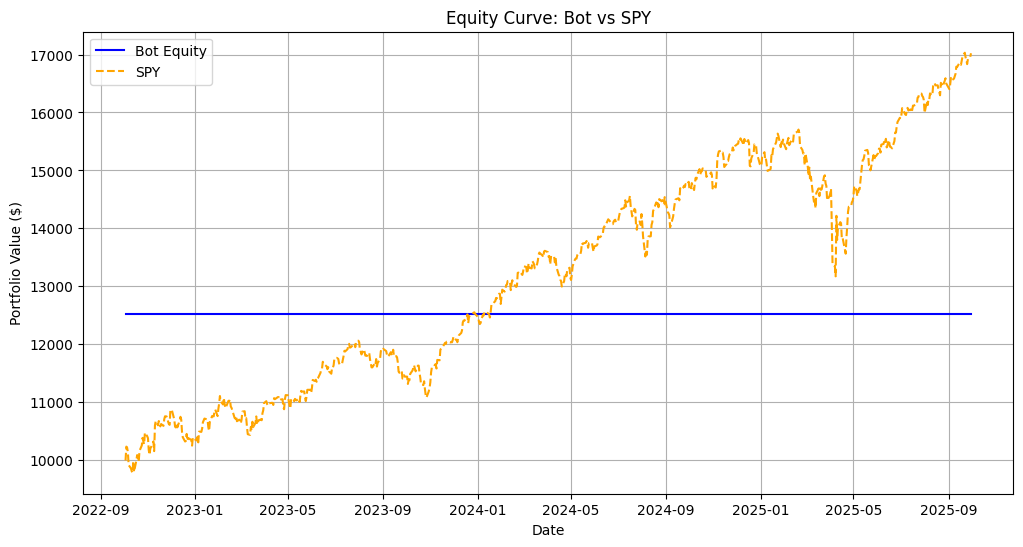

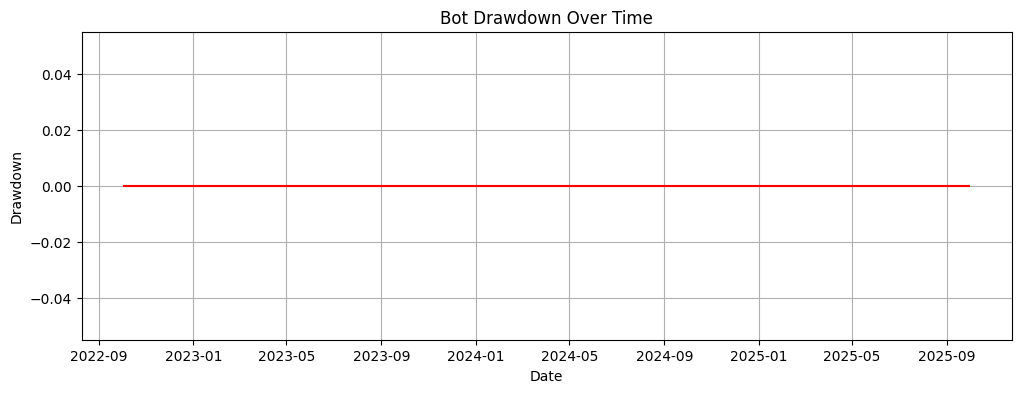

/tmp/ipython-input-1627890883.py:77: RuntimeWarning: invalid value encountered in scalar divide
  sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)


--- PERFORMANCE METRICS ---
+---------------+---------+
| Metric        | Value   |
+===============+=========+
| CAGR          | 7.82%   |
+---------------+---------+
| Sharpe Ratio  | nan     |
+---------------+---------+
| Sortino Ratio | nan     |
+---------------+---------+
| Max Drawdown  | 0.00%   |
+---------------+---------+
| Win Rate      | 49.48%  |
+---------------+---------+
| Profit Factor | nan     |
+---------------+---------+

--- TRADE HISTORY ---
+-----+---------------------+----------+----------+----------+---------+------------+
|     | date                | ticker   | action   |   shares |   price |        pnl |
+=====+=====================+==========+==========+==========+=========+============+
|   0 | 2022-10-03 00:00:00 | AAPL     | buy      |        3 | 140.129 |  nan       |
+-----+---------------------+----------+----------+----------+---------+------------+
|   1 | 2022-10-03 00:00:00 | KO       | buy      |       18 |  51.408 |  nan       |
+-----+------

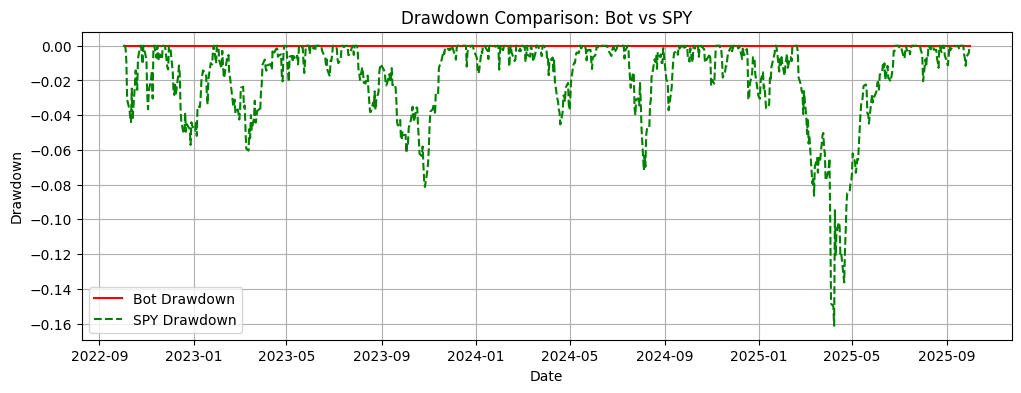

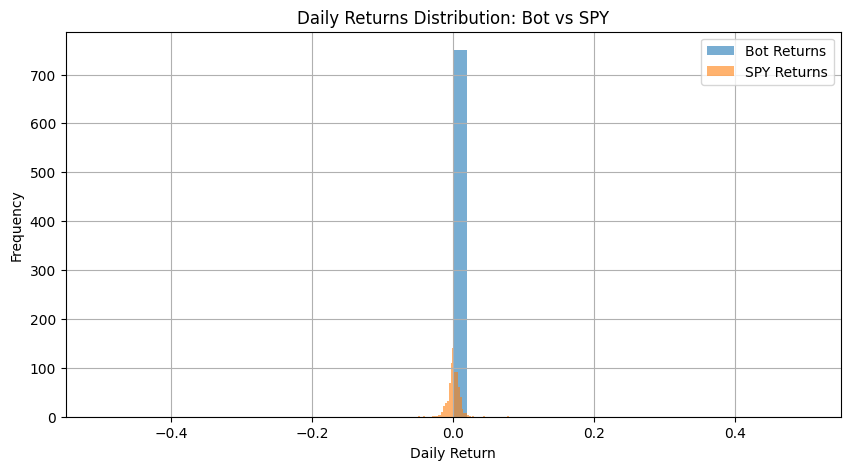

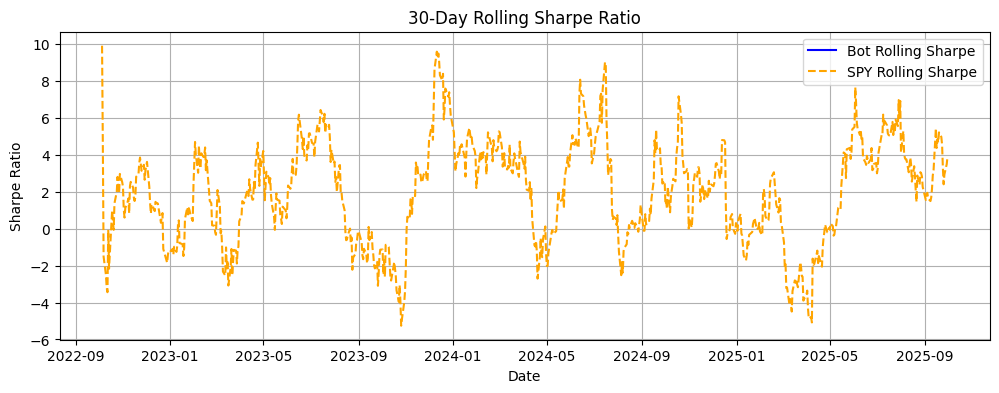

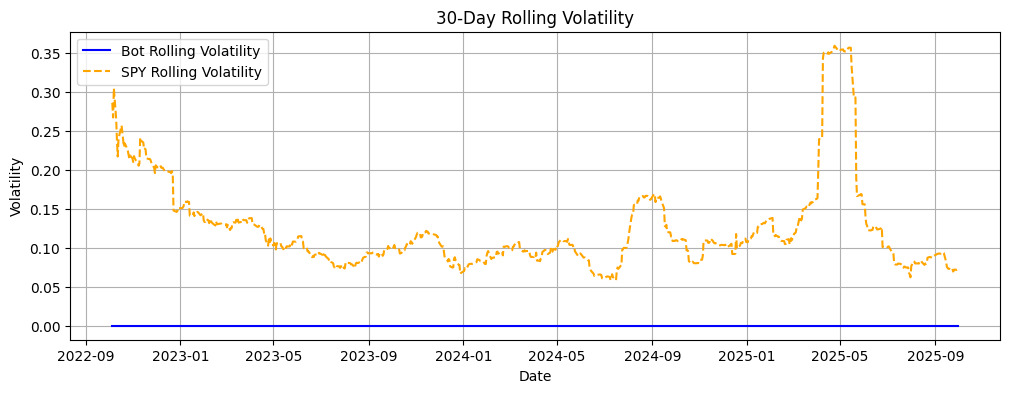

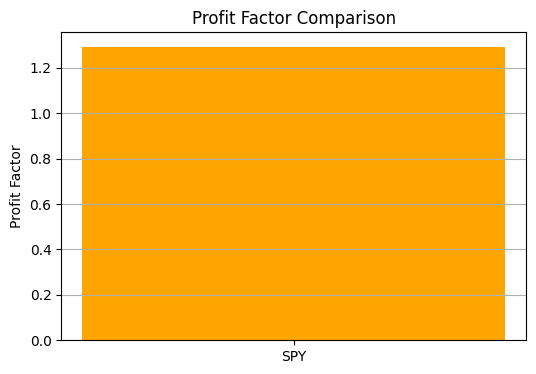

SPY starting cash: $10000.0
SPY final value: $17010.96
Spy CAGR = 19.45%
Spy Sharpe = 1.40
Spy Sortino = 1.98
Spy Max DD = -16.13%
Spy Win Rate = 55.47%
Spy Profit Factor = 1.29


In [ ]:
# --- Compute Bot Equity ---
portfolio_equity = []
for date in test_df.index:
    total_value = portfolio_state['cash']
    for ticker, pos in portfolio_state['positions'].items():
        total_value += pos['shares'] * test_df[f'{ticker}_Close'].loc[date]
    portfolio_equity.append(total_value)

portfolio_equity = pd.Series(portfolio_equity, index=test_df.index)

# --- SPY PASSIVE INVESTING (re-defined for self-containment) ---
spy_start_cash = 10000.0
transaction_fee = 0.0005
slippage_rate = 0.0002

# --- BUY ---
spy_start_price = spy_data['Close'].iloc[0].item()
effective_buy_price = spy_start_price * (1 + slippage_rate)
spy_shares = int(spy_start_cash // effective_buy_price)
spy_buy_cost = spy_shares * effective_buy_price * (1 + transaction_fee)
spy_remaining_cash = spy_start_cash - spy_buy_cost

# --- SELL ---
spy_final_price = spy_data['Close'].iloc[-1].item()
effective_sell_price = spy_final_price * (1 - slippage_rate)
gross_sell_value = spy_shares * effective_sell_price
net_sell_value = gross_sell_value * (1 - transaction_fee)
spy_final_value = net_sell_value + spy_remaining_cash

# --- Compute SPY Equity ---
spy_equity = (spy_shares * spy_close) + spy_remaining_cash
spy_equity = spy_equity.reindex(portfolio_equity.index, method='ffill')


# --- Basic Summary ---
final_portfolio_value = portfolio_equity.iloc[-1]
total_return = (final_portfolio_value - starting_cash) / starting_cash * 100
winning_to_losing_ratio = f"{wins}:{losses}"
unused_cash = portfolio_state['cash']

print("--- BOT PERFORMANCE SUMMARY ---")
print(f"Starting cash: ${starting_cash:,.2f}")
print(f"Final portfolio value: ${final_portfolio_value:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"Winning to losing ratio: {winning_to_losing_ratio}")
print(f"Cash remaining (unused): ${unused_cash:,.2f}\n")

# --- Equity Curve ---
plt.figure(figsize=(12,6))
plt.plot(portfolio_equity, label='Bot Equity', color='blue')
plt.plot(spy_equity, label='SPY', color='orange', linestyle='--')
plt.title('Equity Curve: Bot vs SPY')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

# --- Drawdown Plot (Bot Only) ---
roll_max = portfolio_equity.cummax()
drawdown = (portfolio_equity - roll_max) / roll_max

plt.figure(figsize=(12,4))
plt.plot(drawdown, color='red')
plt.title('Bot Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.show()

# --- Performance Metrics ---
daily_returns = portfolio_equity.pct_change().dropna()
spy_returns = spy_equity.pct_change().dropna()
total_years = (portfolio_equity.index[-1] - portfolio_equity.index[0]).days / 365

CAGR = (final_portfolio_value / starting_cash) ** (1/total_years) - 1
sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
downside_std = daily_returns[daily_returns < 0].std()
sortino_ratio = daily_returns.mean() / downside_std * np.sqrt(252) if downside_std > 0 else np.nan
max_drawdown = drawdown.min()
win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0
profit_factor = sum(r for r in daily_returns if r > 0) / abs(sum(r for r in daily_returns if r < 0)) if any(daily_returns < 0) else np.nan

metrics = pd.DataFrame({
    'Metric': ['CAGR', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Win Rate', 'Profit Factor'],
    'Value': [f"{CAGR:.2%}", f"{sharpe_ratio:.2f}", f"{sortino_ratio:.2f}", f"{max_drawdown:.2%}", f"{win_rate:.2%}", f"{profit_factor:.2f}"]
})
print("--- PERFORMANCE METRICS ---")
print(tabulate(metrics, headers='keys', tablefmt='grid', showindex=False))

# --- Trade History ---
if portfolio_state['trade history']:
    trade_df = pd.DataFrame(portfolio_state['trade history'])
    trade_df['price'] = trade_df['price'].apply(lambda x: f"{x:.3f}")
    trade_df['pnl'] = trade_df.get('pnl', pd.Series([None]*len(trade_df))).apply(lambda x: f"{x:.5f}" if x is not None else "")
    columns_order = ['date', 'ticker', 'action', 'shares', 'price', 'pnl']
    trade_df = trade_df[columns_order]

    print("\n--- TRADE HISTORY ---")
    print(tabulate(trade_df, headers='keys', tablefmt='grid', showindex=True))
else:
    print("No trades executed.")

# --- ADDITIONAL COMPARATIVE GRAPHS ---

# --- Drawdown Comparison ---
bot_roll_max = portfolio_equity.cummax()
bot_drawdown = (portfolio_equity - bot_roll_max) / bot_roll_max

spy_roll_max = spy_equity.cummax()
spy_drawdown = (spy_equity - spy_roll_max) / spy_roll_max

plt.figure(figsize=(12,4))
plt.plot(bot_drawdown, label='Bot Drawdown', color='red')
plt.plot(spy_drawdown, label='SPY Drawdown', color='green', linestyle='--')
plt.title('Drawdown Comparison: Bot vs SPY')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# --- Daily Returns Distribution ---
plt.figure(figsize=(10,5))
plt.hist(daily_returns, bins=50, alpha=0.6, label='Bot Returns')
plt.hist(spy_returns.iloc[:,0], bins=50, alpha=0.6, label='SPY Returns')
plt.title('Daily Returns Distribution: Bot vs SPY')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# --- Rolling Metrics Comparison ---
rolling_window = 30
min_periods = 1

rolling_sharpe_bot = daily_returns.rolling(rolling_window, min_periods=min_periods).mean() / \
                     daily_returns.rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)
rolling_sharpe_spy = spy_returns.iloc[:,0].rolling(rolling_window, min_periods=min_periods).mean() / \
                     spy_returns.iloc[:,0].rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(rolling_sharpe_bot, label='Bot Rolling Sharpe', color='blue')
plt.plot(rolling_sharpe_spy, label='SPY Rolling Sharpe', color='orange', linestyle='--')
plt.title(f'{rolling_window}-Day Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()

rolling_vol_bot = daily_returns.rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)
rolling_vol_spy = spy_returns.iloc[:,0].rolling(rolling_window, min_periods=min_periods).std() * np.sqrt(252)

plt.figure(figsize=(12,4))
plt.plot(rolling_vol_bot, label='Bot Rolling Volatility', color='blue')
plt.plot(rolling_vol_spy, label='SPY Rolling Volatility', color='orange', linestyle='--')
plt.title(f'{rolling_window}-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

# --- Profit Factor Comparison ---
bot_profit_factor = sum(r for r in daily_returns if r > 0) / abs(sum(r for r in daily_returns if r < 0)) if any(daily_returns < 0) else np.nan
spy_profit_factor = sum(r for r in spy_returns.iloc[:,0] if r > 0) / abs(sum(r for r in spy_returns.iloc[:,0] if r < 0)) if any(spy_returns.iloc[:,0] < 0) else np.nan

plt.figure(figsize=(6,4))
plt.bar(['Bot', 'SPY'], [bot_profit_factor, spy_profit_factor], color=['blue', 'orange'])
plt.title('Profit Factor Comparison')
plt.ylabel('Profit Factor')
plt.grid(True, axis='y')
plt.show()

# SPY final value
print(f"SPY starting cash: ${spy_start_cash}")
print(f"SPY final value: ${spy_final_value:.2f}")

# Daily returns
spy_returns = spy_equity.pct_change().dropna()
total_years = (spy_equity.index[-1] - spy_equity.index[0]).days / 365.25

# Metrics
spy_CAGR = (spy_equity.iloc[-1].item() / spy_start_cash) ** (1/total_years) - 1
spy_sharpe = spy_returns.iloc[:,0].mean() / spy_returns.iloc[:,0].std() * np.sqrt(252)
spy_downside_std = spy_returns.iloc[:,0][spy_returns.iloc[:,0] < 0].std()
spy_sortino = spy_returns.iloc[:,0].mean() / spy_downside_std * np.sqrt(252) if spy_downside_std > 0 else np.nan
spy_roll_max = spy_equity.cummax()
spy_drawdown = (spy_equity - spy_roll_max) / spy_roll_max
spy_max_dd = spy_drawdown.min().item()
spy_win_rate = (spy_returns.iloc[:,0] > 0).sum() / len(spy_returns.iloc[:,0])
spy_profit_factor = (sum(r for r in spy_returns.iloc[:,0] if r > 0) / abs(sum(r for r in spy_returns.iloc[:,0] if r < 0))) if any(spy_returns.iloc[:,0] < 0) else np.nan

# Print metrics
print(f"Spy CAGR = {spy_CAGR:.2%}")
print(f"Spy Sharpe = {spy_sharpe:.2f}")
print(f"Spy Sortino = {spy_sortino:.2f}")
print(f"Spy Max DD = {spy_max_dd:.2%}")
print(f"Spy Win Rate = {spy_win_rate:.2%}")
print(f"Spy Profit Factor = {spy_profit_factor:.2f}")

In [ ]:
# MONTE CARLO SIMULATION

simulation_total_return = []
number_simulation = 5000

for i in range(number_simulation):
  random_daily_return = np.random.choice(daily_returns, size=len(daily_returns),replace=True)
  cumulative_returns = np.prod(random_daily_return + 1) - 1
  simulation_total_return.append(cumulative_returns)

print(simulation_total_return)

# Analyze
print(f"Median: {np.median(simulation_total_return)}")
print(f"5th percentile: {np.percentile(simulation_total_return, 5)}")
print(f"95th percentile: {np.percentile(simulation_total_return, 95)}")

# Calculate SPY's total return for comparison
spy_total_return_scalar = (spy_equity.iloc[-1].item() / starting_cash) - 1

print(f"Probability of bot > SPY: {(np.array(simulation_total_return) > spy_total_return_scalar).mean() * 100}")

[np.float64(0.5428175922857186), np.float64(0.17480551583165949), np.float64(1.1157311978982398), np.float64(0.6801290561860549), np.float64(0.38269916084695854), np.float64(0.5846358696305971), np.float64(0.14331881936229407), np.float64(0.35241530194134296), np.float64(0.39263327471698295), np.float64(0.7919587728530078), np.float64(0.5383562328815663), np.float64(0.9308636691332977), np.float64(0.6850526967959041), np.float64(0.4477047698928871), np.float64(0.43469213268913465), np.float64(0.5384093830591352), np.float64(0.2778809643496376), np.float64(0.10182856667856255), np.float64(0.708004680138405), np.float64(0.5416914797458372), np.float64(0.5286012375745135), np.float64(0.7847394676709516), np.float64(0.6051169320757213), np.float64(0.1832503884832335), np.float64(0.11773414296685836), np.float64(1.1280427755843436), np.float64(0.9571252792677725), np.float64(0.577234922346439), np.float64(0.4961965245224049), np.float64(0.3587420677196751), np.float64(0.6716376275090963), n